In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

# <u>Simple Linear Regression (one feature)</u>

## Overview

* [1. Problem setup](#setup)
* [2. Assumptions](#assume)
* [3. Generate data](#data)
* [4. Minimization problem](#min)
* [5. Mathematics](#math)
* [6. Gradient Descent](#gd)
* [7. Batch Gradient Descent](#gd)
* [8. Stochastic Gradient Descent (SGD)](#sgd)
* [9. Implementation](#imple)
* [10. Scikit-Learn Implementation](#scikit)
* [11. Limitations](#limits)
    



<a class="anchor" id="setup"></a>
## 1. Problem setup

In this notebook, I will build a **Simple Linear Regression model** to predict house prices based on the **size of a house**.

The goal is to learn the relationship between **house size (input feature)** and **house price (target variable)** using a linear model.

### Variables

* **Size** — Size of the house (input feature)
* **Price** — Price of the house (target variable)

In real life the model looks like this:

$$
\text{Price} = \beta_0 + \beta_1 \cdot \text{Size} + \varepsilon
$$

where $\varepsilon$ are error terms for each house distorting the true relationship between Price and Size.

The model will learn a relationship of the form:

$$
\text{Price} = \beta_0 + \beta_1 \cdot \text{Size} 
$$

where **$\beta_1$** is the slope and **$\beta_0$** is the intercept. Once trained, the model can be used to **predict the price of a house based on its size**.




<a class="anchor" id="assume"></a>
## 2. Assumptions

| Assumption | Description | Why It Matters |
|------------|-------------|---------------|
| Linearity | The relationship between the independent variable *Size* and the dependent variable *Price* is linear. | Ensures the model can properly represent the relationship using a straight line. |
| Independence of Observations | Each observation in the dataset is independent of the others. | Prevents correlated errors and ensures valid statistical analysis. |
| Homoscedasticity | The variance of the errors (residuals) is constant across all values of *Size*. | Ensures reliable estimation of standard errors and model stability. |
| Errors around zero | The errors are centerd around 0 | Necessary for the line to fit well. |
| Normality of Errors | The residuals are normally distributed. | Required for valid hypothesis testing, confidence intervals, and p-values. |
| No Extreme Outliers | The dataset should not contain extreme values that strongly influence the regression line. | Outliers can significantly distort the slope and intercept estimates. |

I will break down this table and explain it in more detail in the next section.


<a class="anchor" id="data"></a>
## 3. Generate Data

### Linearity

Simple linear regression assumes linearity because it tries to fit a straight line. If the relationship between the feature and target is not roughly linear, the line cannot model it well. Linear means that if one variable increases the other should also increase or decrease. This kind of elationship should be visible when plotting the data.

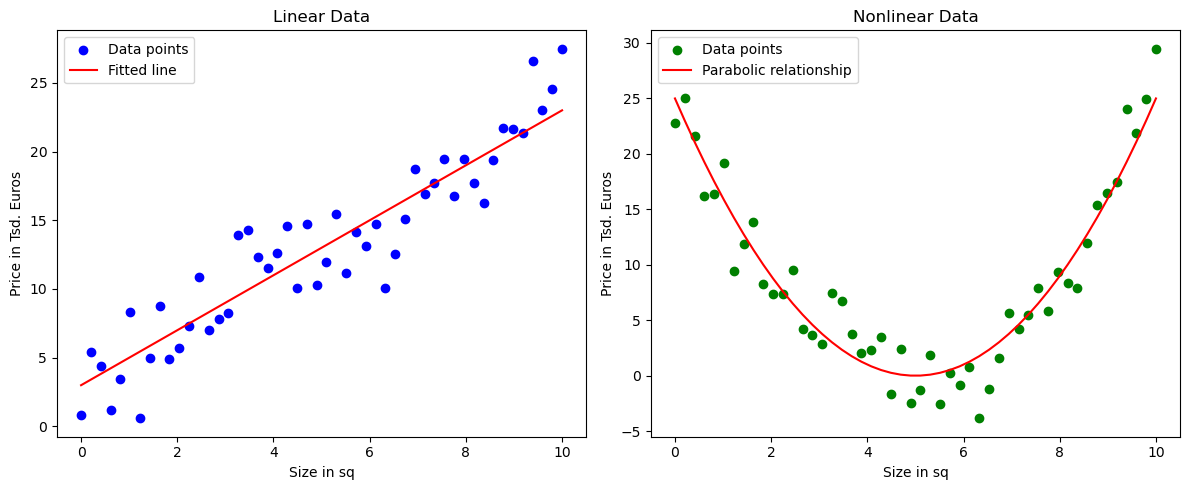

In [ ]:
np.random.seed(123)  # Seed for reproducibility of random numbers

n = 50  # number of houses

# Linear Data
size_linear = np.linspace(0, 10, n) # house sizes in square meters
b0, b1 = 3, 2 # true coefficients
error = np.random.normal(0, 2, n) # error terms to distort true relationship
true_price_linear = b0 + b1 * size_linear + error # price = 2*size + error (price roughly doubles)


# Nonlinear Data 
size_nonlinear = np.linspace(0, 10, n) # house sizes in square meters
true_price_nonlinear = (size_nonlinear - 5)**2 + error

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear data plot
axes[0].scatter(size_linear, true_price_linear, color='blue', label='Data points')
axes[0].plot(size_linear, b0 + b1 * size_linear, color='red', label='Fitted line')
axes[0].set_title("Linear Data")
axes[0].set_xlabel("Size in sq")
axes[0].set_ylabel("Price in Tsd. Euros")
axes[0].legend()

# Nonlinear data plot
axes[1].scatter(size_nonlinear, true_price_nonlinear, color='green', label='Data points')
axes[1].plot(size_nonlinear, (size_nonlinear - 5)**2, color='red', label='Parabolic relationship')
axes[1].set_title("Nonlinear Data")
axes[1].set_xlabel("Size in sq")
axes[1].set_ylabel("Price in Tsd. Euros")
axes[1].legend()

plt.tight_layout()
plt.show()

### Independence of Observations

Dependent observations occur when one data point is influenced by or correlated with another.

Example:

- House prices in the same neighborhood that trend together
- Stock prices over consecutive days (time series data)


How It Affects the Model

1. Coefficients may still be correct

    - Estimated slope $\beta_1$ and intercept $\beta_0$ are still computed the same way.

    - But they assume each data point provides unique information, which is now violated.

2. Residuals are correlated

    - Linear regression assumes residuals (errors) are independent.

    - Dependent observations create correlated residuals, which violates assumptions.

3. Statistical inference becomes unreliable

    - Standard errors, t-tests, p-values, and confidence intervals assume independence.

    - When this assumption is violated, these metrics might give misleading conclusions.


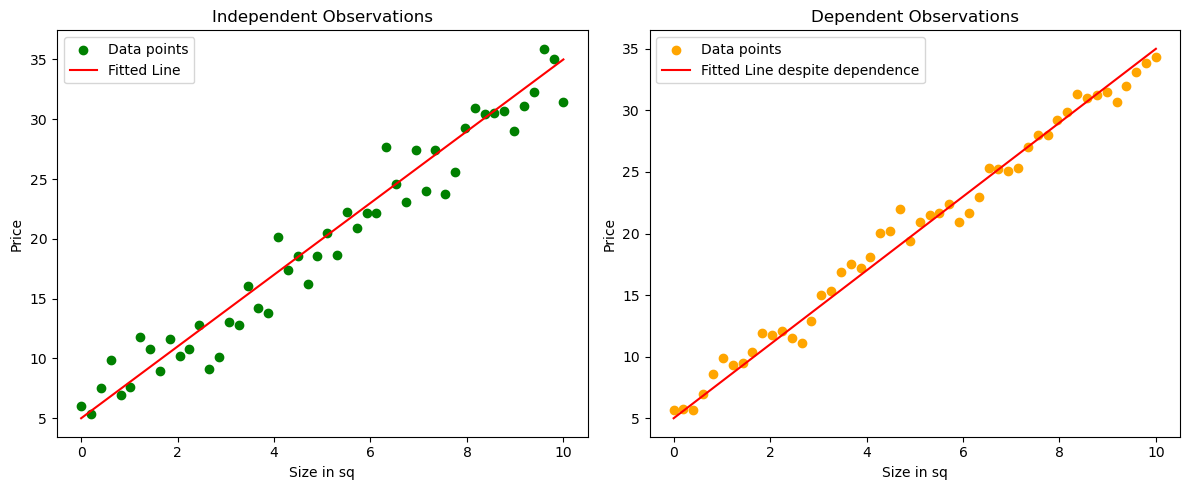

In [168]:
np.random.seed(42)

n = 50 # number of houses
size = np.linspace(0, 10, n) # house sizes in square meters


b0, b1 = 5, 3 # true coefficients
true_price = b0 + b1 * size 


errors_ind = np.random.normal(0, 2, n) # Independent errors
true_price_ind = true_price + errors_ind # true prices from independent observations/independent errors


# Dependent errors (autocorrelated)
errors_dep = np.zeros(n)
errors_dep[0] = np.random.normal(0, 2)

for i in range(1, n):
    errors_dep[i] = 0.8 * errors_dep[i-1] + np.random.normal(0, 1) # next error term is calculated from previous one

true_price_dep = true_price + errors_dep # true prices from dependent observations/dependent errors

# Plot the datasets
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Independent observations
axes[0].scatter(size, true_price_ind,label="Data points",color="green")
axes[0].plot(size, true_price,label="Fitted Line",color="red")
axes[0].set_title("Independent Observations")
axes[0].set_xlabel("Size in sq")
axes[0].set_ylabel("Price")
axes[0].legend()

# Dependent observations
axes[1].scatter(size, true_price_dep,label="Data points",color="orange")
axes[1].plot(size, true_price,label="Fitted Line despite dependence",color="red")
axes[1].set_title("Dependent Observations")
axes[1].set_xlabel("Size in sq")
axes[1].set_ylabel("Price")
axes[1].legend()

plt.tight_layout()
plt.show()

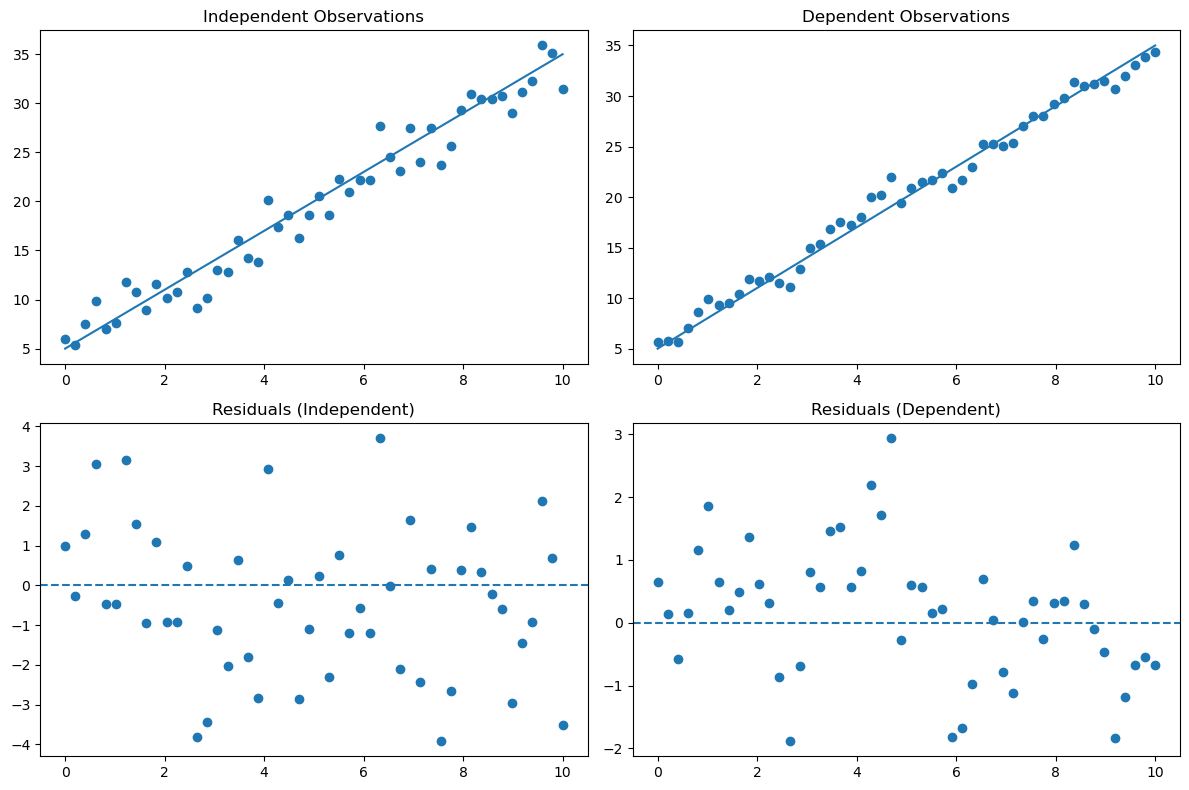

In [161]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 50
x = np.linspace(0, 10, n)

# True model
w = 3
b = 5
y_true = w * x + b

# -----------------------------
# Independent errors
# -----------------------------
errors_ind = np.random.normal(0, 2, n)
y_ind = y_true + errors_ind

# -----------------------------
# Dependent errors
# -----------------------------
errors_dep = np.zeros(n)
errors_dep[0] = np.random.normal(0, 2)

for i in range(1, n):
    errors_dep[i] = 0.8 * errors_dep[i-1] + np.random.normal(0, 1)

y_dep = y_true + errors_dep

# -----------------------------
# Residuals
# -----------------------------
res_ind = y_ind - y_true
res_dep = y_dep - y_true

# -----------------------------
# Plot everything
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Independent data
axes[0,0].scatter(x, y_ind)
axes[0,0].plot(x, y_true)
axes[0,0].set_title("Independent Observations")

# Dependent data
axes[0,1].scatter(x, y_dep)
axes[0,1].plot(x, y_true)
axes[0,1].set_title("Dependent Observations")

# Independent residuals
axes[1,0].scatter(x, res_ind)
axes[1,0].axhline(0, linestyle="--")
axes[1,0].set_title("Residuals (Independent)")

# Dependent residuals
axes[1,1].scatter(x, res_dep)
axes[1,1].axhline(0, linestyle="--")
axes[1,1].set_title("Residuals (Dependent)")

plt.tight_layout()
plt.show()

In [ ]:
# For reproducibility
np.random.seed(42)

# Number of houses
n = 100

# Generate features
num_rooms = np.random.randint(2, 7, n)        # 2–6 rooms
num_baths = np.random.randint(1, 4, n)        # 1–3 bathrooms
garden = np.random.choice(["Yes", "No"], n)   # garden yes/no
age = np.random.randint(0, 50, n)             # house age in years

# Convert garden to numeric effect
garden_value = np.where(garden == "Yes", 15000, 0)

# Generate price using a simple formula + noise
price = (
    50000 +
    num_rooms * 30000 +
    num_baths * 20000 +
    garden_value -
    age * 1000 +
    np.random.normal(0, 10000, n)   # noise
)

# Create dataframe
df = pd.DataFrame({
    "Num_rooms": num_rooms,
    "Num_baths": num_baths,
    "Garden": garden,
    "Age": age,
    "Price": price.astype(int)
})

# Show dataset
print(df.head())